In [2]:
import pandas as pd

df_cdr = pd.read_csv("../data/raw/fraud_detection_cdr.csv")
df_cdr = df_cdr.drop(columns=['Phone Number'])

In [3]:
X= df_cdr.drop(columns=['isFraud'])
y= df_cdr['isFraud']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred= model.predict(X_test)

    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))
    

/Users/ad/Documents/telecom-spam-detection/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic
              precision    recall  f1-score   support

       False       0.90      1.00      0.95     18152
        True       0.00      0.00      0.00      2083

    accuracy                           0.90     20235
   macro avg       0.45      0.50      0.47     20235
weighted avg       0.80      0.90      0.85     20235


Model: Decision Tree
              precision    recall  f1-score   support

       False       0.98      0.98      0.98     18152
        True       0.84      0.85      0.84      2083

    accuracy                           0.97     20235
   macro avg       0.91      0.91      0.91     20235
weighted avg       0.97      0.97      0.97     20235


Model: Random Forest
              precision    recall  f1-score   support

       False       0.98      0.99      0.98     18152
        True       0.87      0.84      0.86      2083

    accuracy                           0.97     20235
   macro avg       0.93      0.91      0.92     20235
weighted avg 

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

models={
    "Logistic": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred= model.predict(X_test)

    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))
    

/Users/ad/Documents/telecom-spam-detection/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic
              precision    recall  f1-score   support

       False       0.92      0.54      0.68     18152
        True       0.13      0.58      0.21      2083

    accuracy                           0.55     20235
   macro avg       0.52      0.56      0.45     20235
weighted avg       0.84      0.55      0.63     20235


Model: Decision Tree
              precision    recall  f1-score   support

       False       0.99      0.96      0.97     18152
        True       0.72      0.89      0.80      2083

    accuracy                           0.95     20235
   macro avg       0.86      0.92      0.89     20235
weighted avg       0.96      0.95      0.96     20235


Model: Random Forest
              precision    recall  f1-score   support

       False       0.98      0.97      0.98     18152
        True       0.76      0.86      0.81      2083

    accuracy                           0.96     20235
   macro avg       0.87      0.92      0.89     20235
weighted avg 

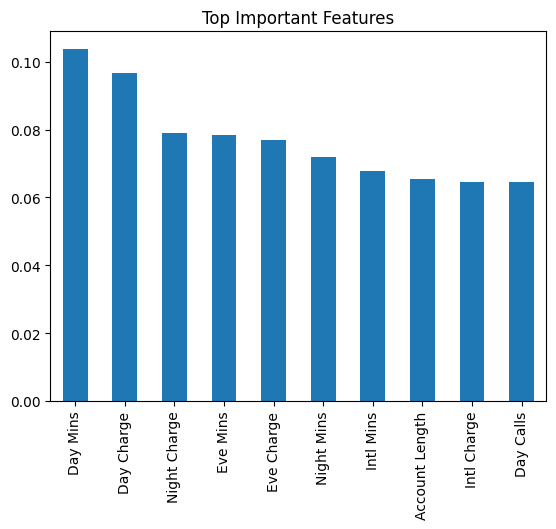

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

model= RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

importances= model.feature_importances_
feature_names= X.columns

feat_imp= pd.Series(importances, index= feature_names)
feat_imp= feat_imp.sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top Important Features")
plt.show()


In [10]:
cols_to_drop= ['Day Charge', 'Eve Charge', 'Night Charge' , 'Intl Charge']
df_cdr= df_cdr.drop(columns= cols_to_drop)


In [ ]:
X = df_cdr.drop(columns=['isFraud'])
y = df_cdr['isFraud']


In [12]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.ensemble import RandomForestClassifier
model= RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)
y_pred= model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.98      0.97      0.98     18152
        True       0.76      0.86      0.81      2083

    accuracy                           0.96     20235
   macro avg       0.87      0.91      0.89     20235
weighted avg       0.96      0.96      0.96     20235

